# Multi Node Graph

আগের notebook-এ আমরা দেখেছিলাম একটা মাত্র node দিয়ে graph বানাতে। কিন্তু বাস্তব জীবনে কাজ কখনো এক ধাপে শেষ হয় না — রান্না করতে হলে প্রথমে কাটাকাটি, তারপর রান্না, তারপর পরিবেশন। LangGraph-এও ঠিক এইভাবে একাধিক node দিয়ে কাজকে ভাগ করা যায়।

## এই notebook-এ যা শিখব:

| বিষয় | বিবরণ |
|---|---|
| Multiple Nodes | একাধিক node তৈরি এবং সংযুক্ত করা |
| `add_edge()` | এক node থেকে আরেক node-এ যাওয়ার রাস্তা বানানো |
| Sequential Flow | ধাপে ধাপে state পরিবর্তন |
| State accumulation | প্রতিটি node কীভাবে state-এ কিছু যোগ করে |

**মূল ধারণা:** এক node শেষ হলে তার output-ই পরবর্তী node-এর input হয়। State টা একটা বলের মতো — এক node থেকে আরেক node-এ ছুঁড়ে দেওয়া হয়।

## Import করা

আগের মতোই — `TypedDict` আর `StateGraph`। এখানে নতুন কিছু import করতে হচ্ছে না।

In [7]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

## State তৈরি করা

এই উদাহরণে আমরা একটা **text processing pipeline** বানাব। ধরো একটা sentence আসবে, সেটাকে তিনটা ধাপে process করব:

1. **Step 1:** Text-কে uppercase করব
2. **Step 2:** শুরুতে আর শেষে `***` যোগ করব
3. **Step 3:** কতটা character আছে সেটা count করে যোগ করব

State-এ দুটো field রাখছি:
- `text` — যে text process হচ্ছে
- `steps` — কোন কোন ধাপ পার হয়েছে সেটার log (list)

In [8]:
class TextState(TypedDict):
    text: str
    steps: List[str]  # কোন কোন ধাপ পার হয়েছে তার log

## তিনটা Node তৈরি করা

প্রতিটা node একটা সাধারণ Python function। নিয়ম একটাই:
- **Input:** পুরো state dictionary
- **Output:** পরিবর্তিত state dictionary

```
Input Text: "hello langgraph"
      ↓
  uppercase_node → "HELLO LANGGRAPH"
      ↓
  decorator_node → "*** HELLO LANGGRAPH ***"
      ↓
  counter_node   → "*** HELLO LANGGRAPH *** [23 chars]"
```

In [9]:
def uppercase_node(state: TextState) -> TextState:
    """Node 1: Text-কে uppercase করে"""
    print(f"📝 Node 1 চলছে... আগের text: '{state['text']}'")
    
    state['text'] = state['text'].upper()
    state['steps'].append("uppercase করা হয়েছে")
    
    print(f"✅ Node 1 শেষ। নতুন text: '{state['text']}'")
    return state


def decorator_node(state: TextState) -> TextState:
    """Node 2: Text-এর চারপাশে *** যোগ করে"""
    print(f"📝 Node 2 চলছে... আগের text: '{state['text']}'")
    
    state['text'] = f"*** {state['text']} ***"
    state['steps'].append("*** দিয়ে সাজানো হয়েছে")
    
    print(f"✅ Node 2 শেষ। নতুন text: '{state['text']}'")
    return state


def counter_node(state: TextState) -> TextState:
    """Node 3: Text-এর character count যোগ করে"""
    print(f"📝 Node 3 চলছে... আগের text: '{state['text']}'")
    
    char_count = len(state['text'])
    state['text'] = f"{state['text']} [{char_count} chars]"
    state['steps'].append(f"character count ({char_count}) যোগ করা হয়েছে")
    
    print(f"✅ Node 3 শেষ। নতুন text: '{state['text']}'")
    return state

## Graph তৈরি এবং Node সংযুক্ত করা

এখানে নতুন জিনিস হলো `add_edge()` — এটা দিয়ে বলা হচ্ছে কোন node-এর পর কোন node আসবে।

```
[START] → uppercase → decorator → counter → [END]
```

| Method | কাজ |
|---|---|
| `add_node(name, func)` | Graph-এ node যোগ করা |
| `add_edge(from, to)` | দুটো node-এর মধ্যে সংযোগ বানানো |
| `set_entry_point(name)` | প্রথম node কোনটা |
| `set_finish_point(name)` | শেষ node কোনটা |

In [10]:
# Graph তৈরি
graph = StateGraph(TextState)

# তিনটা node যোগ করা
graph.add_node("uppercase", uppercase_node)
graph.add_node("decorator", decorator_node)
graph.add_node("counter", counter_node)

# Node-গুলো সংযুক্ত করা — এক node থেকে আরেক node-এ যাওয়ার রাস্তা
graph.add_edge("uppercase", "decorator")  # uppercase শেষে decorator-এ যাবে
graph.add_edge("decorator", "counter")    # decorator শেষে counter-এ যাবে

# শুরু এবং শেষ বলে দেওয়া
graph.set_entry_point("uppercase")  # শুরু uppercase থেকে
graph.set_finish_point("counter")   # শেষ counter-এ

# Compile করা
app = graph.compile()
print("✅ Graph তৈরি সম্পন্ন!")

✅ Graph তৈরি সম্পন্ন!


## Graph-এর চিত্র দেখা

এখন graph-এ তিনটা node আছে, তাই diagram-এ তিনটা box দেখা যাবে এবং তাদের মধ্যে তীর চিহ্ন থাকবে।

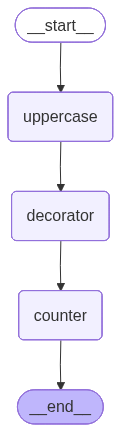

In [11]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Graph চালানো

লক্ষ্য করো — `steps` field-এ একটা **খালি list** দিয়ে শুরু করছি। প্রতিটা node এই list-এ নিজের নাম যোগ করবে, তাহলে শেষে বোঝা যাবে কোন কোন ধাপ পার হয়েছে।

In [12]:
# Initial state — শুরুর অবস্থা
initial_state = {
    "text": "hello langgraph",
    "steps": []  # শুরুতে খালি
}

print("🚀 Graph শুরু হচ্ছে...")
print(f"Initial input: {initial_state}")
print("-" * 50)

result = app.invoke(initial_state)

print("-" * 50)
print("\n🎯 চূড়ান্ত ফলাফল:")
print(f"Final text: {result['text']}")
print(f"\nকোন কোন ধাপ পার হয়েছে:")
for i, step in enumerate(result['steps'], 1):
    print(f"  {i}. {step}")

🚀 Graph শুরু হচ্ছে...
Initial input: {'text': 'hello langgraph', 'steps': []}
--------------------------------------------------
📝 Node 1 চলছে... আগের text: 'hello langgraph'
✅ Node 1 শেষ। নতুন text: 'HELLO LANGGRAPH'
📝 Node 2 চলছে... আগের text: 'HELLO LANGGRAPH'
✅ Node 2 শেষ। নতুন text: '*** HELLO LANGGRAPH ***'
📝 Node 3 চলছে... আগের text: '*** HELLO LANGGRAPH ***'
✅ Node 3 শেষ। নতুন text: '*** HELLO LANGGRAPH *** [23 chars]'
--------------------------------------------------

🎯 চূড়ান্ত ফলাফল:
Final text: *** HELLO LANGGRAPH *** [23 chars]

কোন কোন ধাপ পার হয়েছে:
  1. uppercase করা হয়েছে
  2. *** দিয়ে সাজানো হয়েছে
  3. character count (23) যোগ করা হয়েছে


## নিজে চেষ্টা করো! 🎯

নিচের exercises গুলো নিজে করে দেখো:

**Easy:**
1. আরেকটা node যোগ করো যেটা text-কে reverse করবে
2. Initial state-এ অন্য কোনো text দিয়ে চালাও

**Medium:**
3. State-এ একটা `word_count` field যোগ করো এবং একটা node বানাও যেটা word count করবে
4. চারটা node দিয়ে একটা graph বানাও

**Challenge:**
5. একটা graph বানাও যেটা একটা নামকে নিয়ে বাংলায় পরিচয় বাক্য তৈরি করবে (বিভিন্ন node-এ বিভিন্ন অংশ যোগ করবে)

## সারসংক্ষেপ

এই notebook-এ শিখলাম:

- ✅ **Multiple nodes** — একাধিক function আলাদা আলাদা কাজ করতে পারে
- ✅ **add_edge()** — node-গুলোকে সংযুক্ত করে sequential flow তৈরি করে
- ✅ **State accumulation** — প্রতিটা node state পড়ে, পরিবর্তন করে, এগিয়ে দেয়
- ✅ **Steps logging** — কোন কোন ধাপ পার হয়েছে সেটা track করা

**পরের notebook:** Conditional Edges — মানে, কোন পথে যাবে সেটা runtime-এ সিদ্ধান্ত নেওয়া। যেমন, যদি text বড় হয় তাহলে এক পথে, ছোট হলে আরেক পথে! 🔀